In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
train  = pd.read_csv('train.csv')
meal   = pd.read_csv('meal_info.csv')
center = pd.read_csv('fulfilment_center_info.csv')

print('Train shape  :', train.shape)
print('Meal shape   :', meal.shape)
print('Center shape :', center.shape)

# Merge all three datasets
df = train.merge(meal,   on='meal_id',   how='left')
df = df.merge(center,    on='center_id', how='left')

print('\nMerged df shape:', df.shape)
df.head()

Train shape  : (26402, 9)
Meal shape   : (51, 3)
Center shape : (77, 5)

Merged df shape: (26402, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0.0,0.0,177.0,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0.0,0.0,270.0,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0.0,0.0,189.0,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0.0,0.0,54.0,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0.0,0.0,40.0,Beverages,Indian,647,56,TYPE_C,2.0


In [4]:
print("Data Types & Non-Null Counts ")
df.info()
print('\n Statistical Summary ')
df.describe()

Data Types & Non-Null Counts 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26402 entries, 0 to 26401
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     26402 non-null  int64  
 1   week                   26402 non-null  int64  
 2   center_id              26402 non-null  int64  
 3   meal_id                26402 non-null  int64  
 4   checkout_price         26402 non-null  float64
 5   base_price             26402 non-null  float64
 6   emailer_for_promotion  26401 non-null  float64
 7   homepage_featured      26401 non-null  float64
 8   num_orders             26401 non-null  float64
 9   category               26402 non-null  object 
 10  cuisine                26402 non-null  object 
 11  city_code              26402 non-null  int64  
 12  region_code            26402 non-null  int64  
 13  center_type            26402 non-null  object 
 14  op_area                2

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,2.640200e+04,26402.000000,26402.000000,26402.000000,26402.000000,26402.000000,26401.000000,26401.000000,26401.000000,26402.000000,26402.000000,26402.000000
mean,1.249455e+06,5.091925,82.443603,1980.401371,326.378419,348.947512,0.083292,0.134199,291.629522,601.932202,56.358685,4.085868
std,1.444853e+05,2.670226,46.045556,541.618654,151.902349,151.522087,0.276329,0.340873,605.404041,66.595234,17.533114,1.099563
min,1.000000e+06,1.000000,10.000000,1062.000000,65.960000,90.210000,0.000000,0.000000,13.000000,456.000000,23.000000,0.900000
25%,1.123626e+06,3.000000,43.000000,1543.000000,232.830000,243.500000,0.000000,0.000000,54.000000,553.000000,34.000000,3.600000
50%,1.249568e+06,5.000000,77.000000,1962.000000,290.030000,309.430000,0.000000,0.000000,136.000000,599.000000,56.000000,4.000000
75%,1.374484e+06,7.000000,110.000000,2494.000000,439.462500,447.230000,0.000000,0.000000,325.000000,654.000000,77.000000,4.500000
max,1.499994e+06,10.000000,186.000000,2867.000000,709.130000,728.530000,1.000000,1.000000,24299.000000,713.000000,93.000000,7.000000


In [5]:
print(' Missing Values ')
print(df.isnull().sum())

print('Duplicate Rows')
print(df.duplicated().sum())

 Missing Values 
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    1
homepage_featured        1
num_orders               1
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64
Duplicate Rows
0


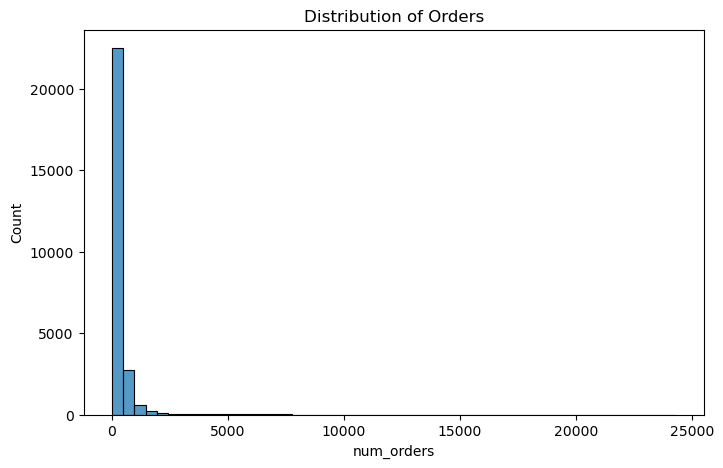

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["num_orders"],
    bins=50
)

plt.title("Distribution of Orders")

plt.show()

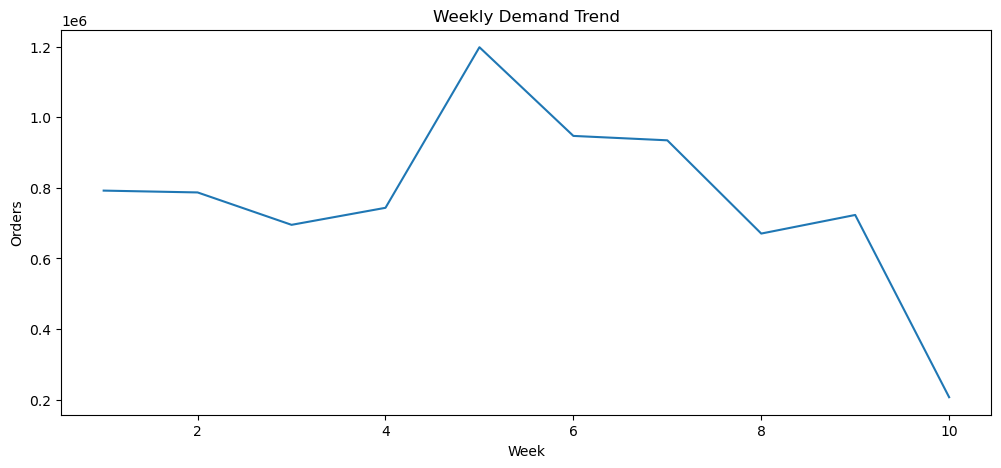

In [7]:
weekly_orders = df.groupby(
    "week"
)["num_orders"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    weekly_orders.index,
    weekly_orders.values
)

plt.title("Weekly Demand Trend")

plt.xlabel("Week")

plt.ylabel("Orders")

plt.show()

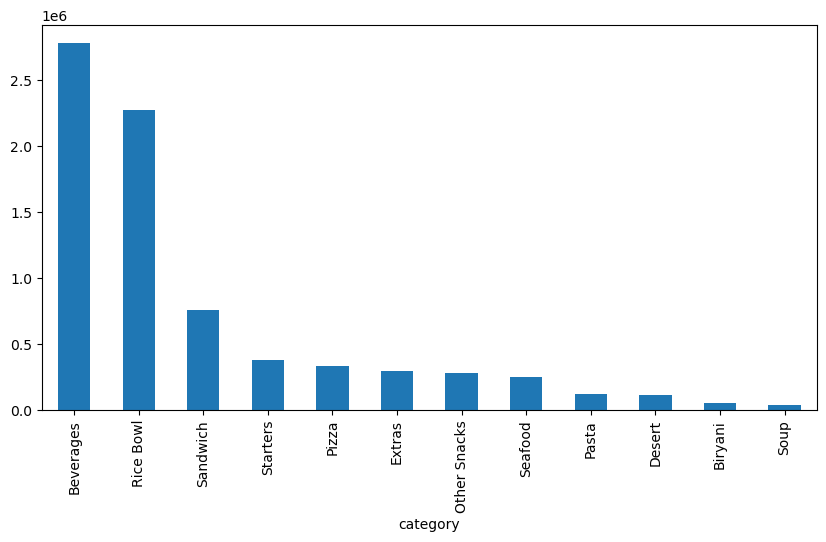

In [8]:
plt.figure(figsize=(10,5))

df.groupby(
    "category"
)["num_orders"].sum().sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.show()

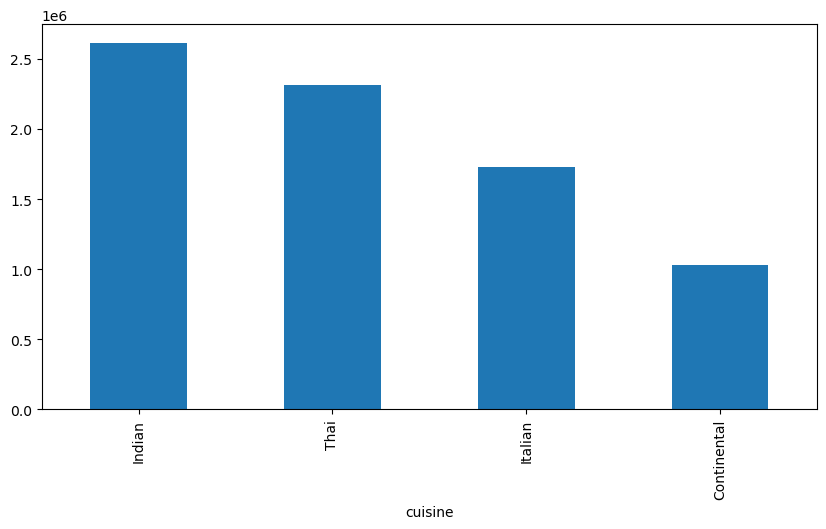

In [9]:
plt.figure(figsize=(10,5))

df.groupby(
    "cuisine"
)["num_orders"].sum().sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.show()

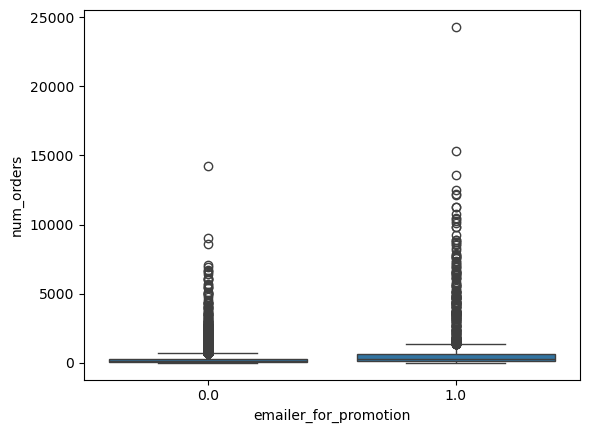

In [10]:
sns.boxplot(
    x="emailer_for_promotion",
    y="num_orders",
    data=df
)

plt.show()

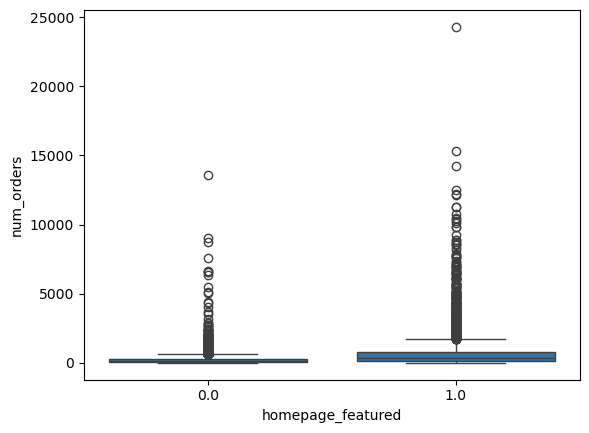

In [11]:
sns.boxplot(
    x="homepage_featured",
    y="num_orders",
    data=df
)

plt.show()

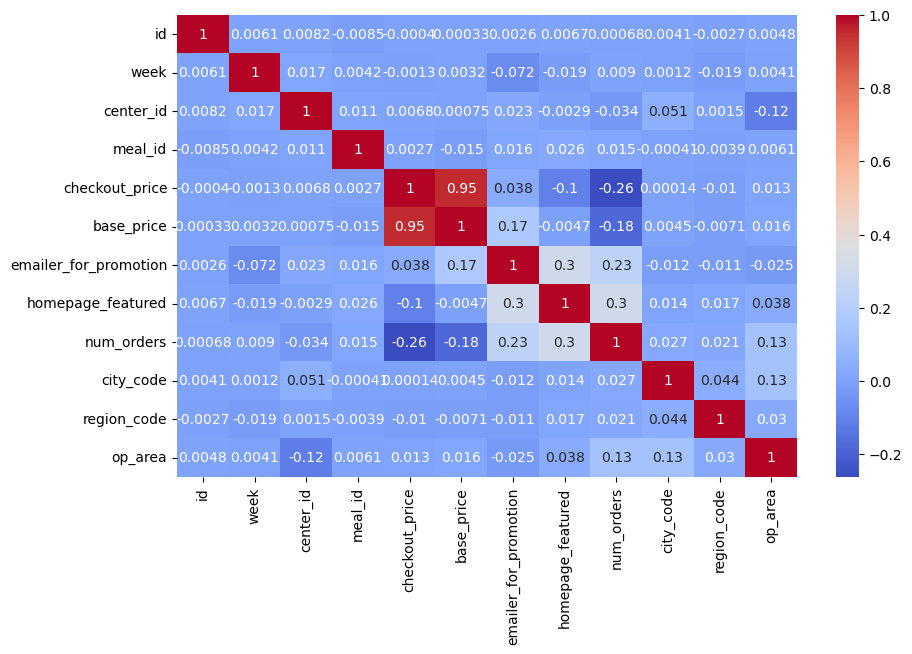

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

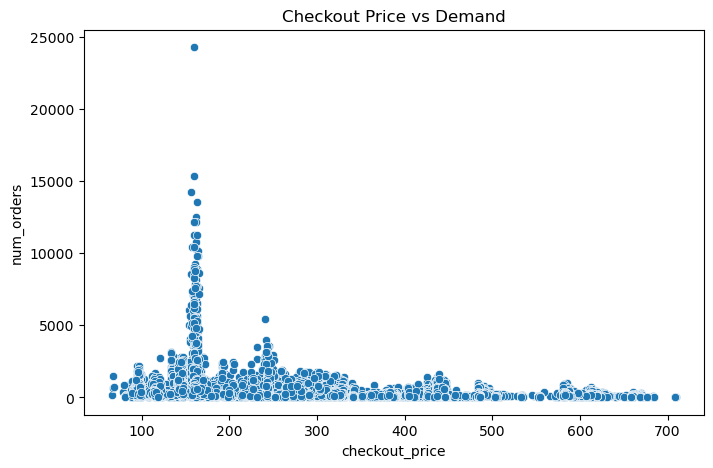

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="checkout_price",
    y="num_orders",
    data=df
)

plt.title("Checkout Price vs Demand")
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["category"] = le.fit_transform(df["category"])
df["cuisine"] = le.fit_transform(df["cuisine"])
df["center_type"] = le.fit_transform(df["center_type"])

In [15]:
for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median())

In [16]:
df.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

In [24]:
X = df.drop(
    ["num_orders","center_id","meal_id"],
    axis=1
)

X.select_dtypes(include="object").columns



Index([], dtype='object')

In [28]:
y = df["num_orders"]

In [29]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
df[['category','cuisine','center_type']].head()

,category,cuisine,center_type
0,0,3,2
1,0,3,2
2,0,3,2
3,0,1,2
4,0,1,2


In [31]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)
# ValueError: could not convert string to float: 'Rice Bowl'

In [32]:
print("MAE")

print(
    mean_absolute_error(
        y_test,
        pred_lr
    )
)

print("RMSE")

print(
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_lr
        )
    )
)

print("R2 Score")

print(
    r2_score(
        y_test,
        pred_lr
    )
)

MAE
255.08468645166136
RMSE
590.6002125552171
R2 Score
0.23553153416336803


In [35]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

In [36]:
print("MAE")

print(
    mean_absolute_error(
        y_test,
        pred_rf
    )
)

print("RMSE")

print(
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_rf
        )
    )
)

print("R2 Score")

print(
    r2_score(
        y_test,
        pred_rf
    )
)

MAE
101.2894300321909
RMSE
265.00050900152263
R2 Score
0.8460903700739325


In [38]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,category,0.272365
2,checkout_price,0.184387
4,emailer_for_promotion,0.148458
11,op_area,0.128136
3,base_price,0.069123
0,id,0.041780
5,homepage_featured,0.040729
1,week,0.039877
8,city_code,0.034641
9,region_code,0.015079


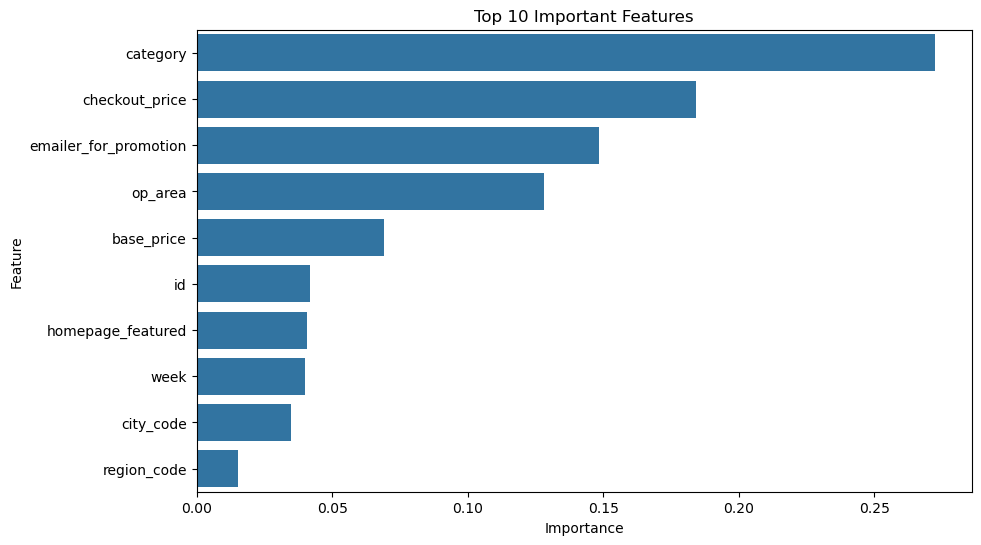

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [40]:
comparison = pd.DataFrame({

    "Model":["Linear Regression","Random Forest"],

    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

comparison

,Model,R2
0,Linear Regression,0.235532
1,Random Forest,0.846090


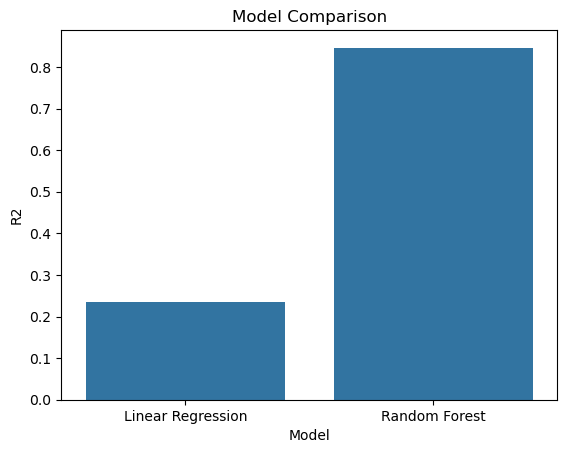

In [41]:
sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title("Model Comparison")
plt.show()

In [ ]:
# 1. Promotional campaigns significantly increase meal demand.

# 2. Homepage featured meals receive more orders.

# 3. Certain cuisines consistently outperform others.

# 4. Demand varies across fulfillment centers and regions.

# 5. Forecasting demand helps optimize inventory and reduce food wastage.

# 6. Accurate forecasting improves operational planning and profitability.